# Analiza NHL sezon (2000-2024)

V analizi sem pregledala podatke o NHL sezonah med letoma 2000 in 2024 – 
prvake (Stanley Cup), MVP-je lige (Hart Memorial Trophy) in najboljše strelce ter njihove sezonske statistike.
Podatki so bili pridobljeni s spletne strani hockey-reference.com.

In [29]:
#tabela vseh podatov
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("nhl_sezone.csv")

df

,sezona,prvak,mvp,mvp_goli,mvp_asistence,mvp_tocke,mvp_zmage,mvp_porazi,mvp_otl,mvp_gaa,najboljsi_strelec,najboljsi_strelec_tocke
0,2000,New Jersey Devils,Chris Pronger,14.0,48.0,62.0,NaN,NaN,NaN,NaN,Jaromír Jágr,96.0
1,2001,Colorado Avalanche,Joe Sakic,54.0,64.0,118.0,NaN,NaN,NaN,NaN,Jaromír Jágr,121.0
2,2002,Detroit Red Wings,José Théodore,NaN,NaN,NaN,30.0,24.0,10.0,2.11,Jarome Iginla,96.0
3,2003,New Jersey Devils,Peter Forsberg,29.0,77.0,106.0,NaN,NaN,NaN,NaN,Peter Forsberg,106.0
4,2004,Tampa Bay Lightning,Martin St. Louis,38.0,56.0,94.0,NaN,NaN,NaN,NaN,Martin St. Louis,94.0
5,2005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2006,Carolina Hurricanes,Joe Thornton,29.0,96.0,125.0,NaN,NaN,NaN,NaN,Joe Thornton,125.0
7,2007,Anaheim Ducks,Sidney Crosby,36.0,84.0,120.0,NaN,NaN,NaN,NaN,Sidney Crosby,120.0
8,2008,Detroit Red Wings,Alex Ovechkin,65.0,47.0,112.0,NaN,NaN,NaN,NaN,Alex Ovechkin,112.0
9,2009,Pittsburgh Penguins,Alex Ovechkin,56.0,54.0,110.0,NaN,NaN,NaN,NaN,Evgeni Malkin,113.0


Zgornja tabela predstavlja prvaka, mvp in njegove statistike in podobno za najboljšega strelca za vsako sezono med letoma 2000 in 2024. Ker sta mvp lahko vratar ali pa igralec na eni izmed drugih pozicij, je tabela narejena z obema možnostima. Če je mvp vratar, kot v letih 2002 in 2015, potem je pri vseh statističnih podatkih za napadalce ali branilce podatek označen kot NaN. Prav tako če mvp ni vratar, je NaN pri vseh stolpcih s podatki za vratarje.

MVP je bil Napadalec/Branilec v 22 sezonah.
MVP je bil vratar v 2 sezonah.


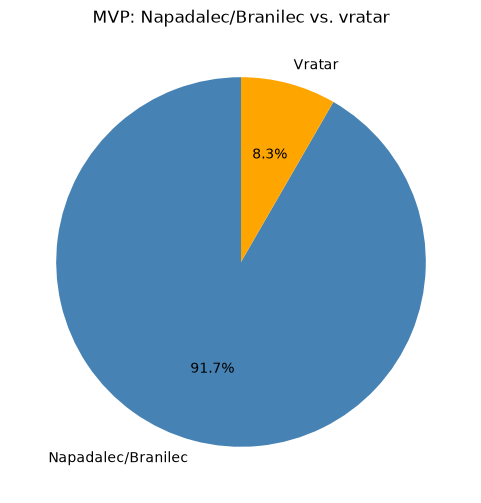

In [ ]:
#kokrat je bil mvp vratar in kokrat napadalec/branilec
stevilo_igralcev = df["mvp_tocke"].notna().sum()
stevilo_vratarjev = df["mvp_gaa"].notna().sum()

print(f"MVP je bil Napadalec/Branilec v {stevilo_igralcev} sezonah.")
print(f"MVP je bil vratar v {stevilo_vratarjev} sezonah.")

plt.figure(figsize=(6, 6))
plt.pie(
    [stevilo_igralcev, stevilo_vratarjev],
    labels=["Napadalec/Branilec", "Vratar"],
    colors=["steelblue", "orange"],
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("MVP: Napadalec/Branilec vs. vratar")
plt.show()

V analiziranem obdobju (2000–2024) je bil MVP lige (Hart Memorial Trophy) v veliki 
večini sezon (22 od 24, kjer je bila sezona odigrana) osvojen s strani igralca 
(napadalca ali branilca), medtem ko je bil vratar MVP le v dveh sezonah. To je 
pričakovano, saj vratarji redkeje prejmejo to nagrado, saj običajno nagrada nagrajuje ofenzivno uspešnost.

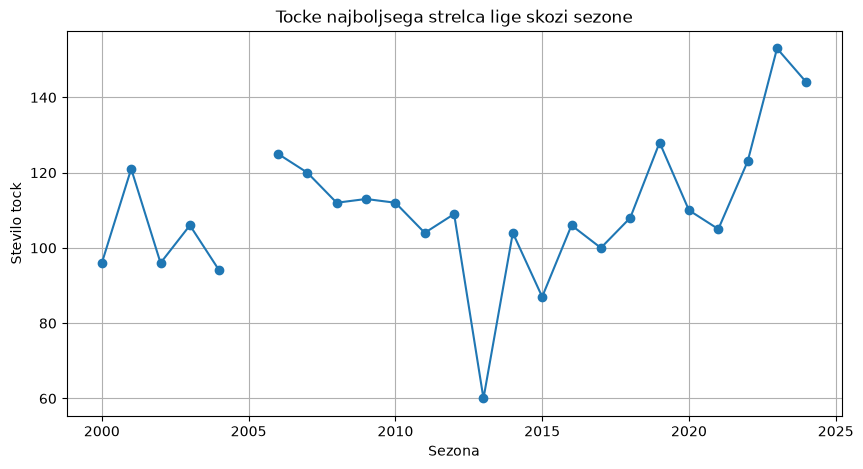

In [28]:
#st tock najbolsega strelca za vsako sezono
plt.figure(figsize=(10, 5))
plt.plot(df["sezona"], df["najboljsi_strelec_tocke"], marker="o")
plt.title("Tocke najboljsega strelca lige skozi sezone")
plt.xlabel("Sezona")
plt.ylabel("Stevilo tock")
plt.grid(True)
plt.show()

Iz grafa je razvidno, da je leta 2005 prekinitev, ker je bila takrat celotna sezona NHL 
odpovedana zaradi delavskega spora ("lockout"). Prav tako opazimo izrazit upad okoli 
leta 2013 – takrat je bila sezona zaradi podobnega spora skrajšana na samo 48 tekem 
namesto običajnih 82, kar je močno zmanjšalo skupno število doseženih točk 
najboljšega strelca lige.

In [ ]:
# kokrat je bil mvp tudi najbolsi strelec
ujemanje = df["mvp"] == df["najboljsi_strelec"]
stevilo_ujemanj = ujemanje.sum()

print(f"MVP je bil hkrati tudi najboljsi strelec lige v {stevilo_ujemanj} sezonah.")

# izpisemo, v katerih letih se je to zgodilo
print(df[ujemanje][["sezona", "mvp"]])

MVP je bil hkrati tudi najboljsi strelec lige v 14 sezonah.
    sezona               mvp
3     2003    Peter Forsberg
4     2004  Martin St. Louis
6     2006      Joe Thornton
7     2007     Sidney Crosby
8     2008     Alex Ovechkin
10    2010      Henrik Sedin
12    2012     Evgeni Malkin
14    2014     Sidney Crosby
16    2016      Patrick Kane
17    2017    Connor McDavid
19    2019   Nikita Kucherov
20    2020    Leon Draisaitl
21    2021    Connor McDavid
23    2023    Connor McDavid


V 14 od 24 odigranih sezon (58 %) je bil MVP lige hkrati tudi najboljši strelec 
lige po točkah – kar kaže na močno povezavo med produktivnostjo igralca in 
osvojitvijo nagrade MVP. Connor McDavid je edini igralec, ki je to dosegel 
trikrat (2017, 2021, 2023), Sidney Crosby pa dvakrat (2007, 2014).

In [27]:
# kolikokrat je bil posamezen igralec iz tabele mvp
najveckrat_mvp = df["mvp"].value_counts().head(5)
print("Najveckrat MVP:")
print(najveckrat_mvp)

print()

# stejemo, kolikokrat se pojavi vsako ime v stolpcu najboljsi_strelec
najveckrat_strelec = df["najboljsi_strelec"].value_counts().head(5)
print("Najveckrat najboljsi strelec:")
print(najveckrat_strelec)

Najveckrat MVP:
mvp
Alex Ovechkin     3
Connor McDavid    3
Sidney Crosby     2
Chris Pronger     1
Joe Sakic         1
Name: count, dtype: int64

Najveckrat najboljsi strelec:
najboljsi_strelec
Connor McDavid      5
Jaromír Jágr        2
Martin St. Louis    2
Sidney Crosby       2
Evgeni Malkin       2
Name: count, dtype: int64


Alex Ovechkin in Connor McDavid sta v analiziranem obdobju vsak trikrat osvojila 
naziv MVP lige, kar ju uvršča na vrh seznama najuspešnejših igralcev tega obdobja. 
Še bolj izstopa Connor McDavid pri številu točk – bil je najboljši strelec lige 
kar 5-krat, kar je znatno več kot katerikoli drug igralec v tem obdobju (drugo 
mesto si deli več igralcev z le 2 nastopoma na vrhu lestvice strelcev).

prvak
Tampa Bay Lightning     3
Pittsburgh Penguins     3
Chicago Blackhawks      3
New Jersey Devils       2
Colorado Avalanche      2
Detroit Red Wings       2
Los Angeles Kings       2
Carolina Hurricanes     1
Anaheim Ducks           1
Boston Bruins           1
Washington Capitals     1
St. Louis Blues         1
Vegas Golden Knights    1
Florida Panthers        1
Name: count, dtype: int64


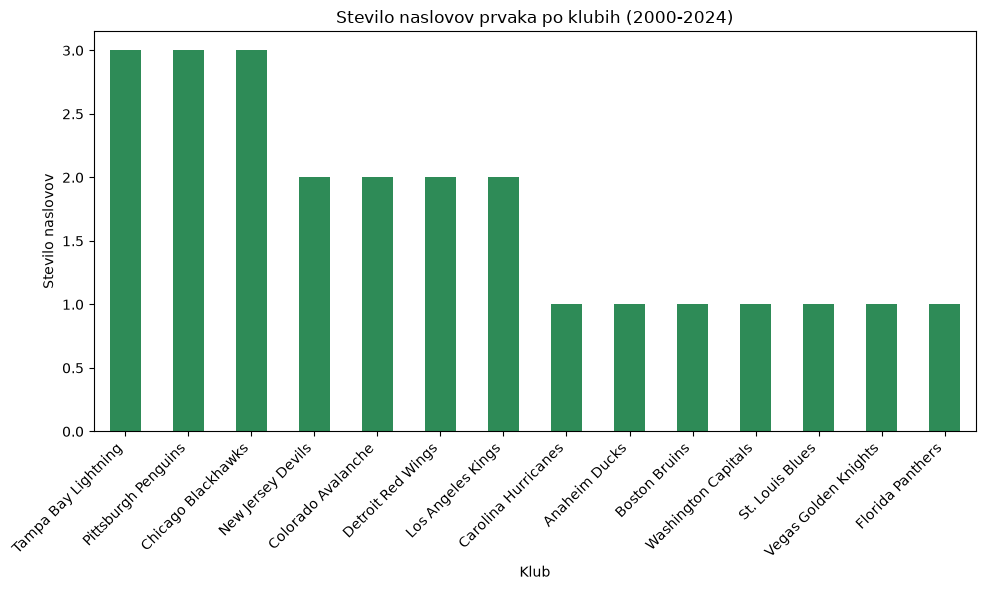

In [26]:
# kolikokrat je bil vsak klub prvak
najveckrat_prvak = df["prvak"].value_counts()

print(najveckrat_prvak)

plt.figure(figsize=(10, 6))
najveckrat_prvak.plot(kind="bar", color="seagreen")
plt.title("Stevilo naslovov prvaka po klubih (2000-2024)")
plt.xlabel("Klub")
plt.ylabel("Stevilo naslovov")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Tri klube – Tampa Bay Lightning, Pittsburgh Penguins in Chicago Blackhawks – lahko 
označimo kot najuspešnejše v analiziranem obdobju, saj so vsak trikrat osvojili 
Stanley Cup. Sledijo jim New Jersey Devils, Colorado Avalanche, Detroit Red Wings 
in Los Angeles Kings z dvema naslovoma. Preostalih sedem klubov je naslov osvojilo 
enkrat, kar kaže na razmeroma enakomerno porazdelitev uspeha med večjim številom 
različnih ekip v primerjavi s samo nekaj dominantnimi klubi.

## Zaključek

Analiza je pokazala nekaj zanimivih vzorcev v NHL statistiki zadnjih 25 sezon:

- Število točk najboljšega strelca skozi leta jasno odraža vpliv dveh NHL 
  "lockoutov" (2005 in 2013), ko so bile sezone odpovedane oziroma skrajšane.
- MVP lige je bil v veliki večini primerov igralec, le v dveh sezonah vratar.
- V 58 % sezon je bil MVP hkrati tudi najboljši strelec lige, kar kaže na močno 
  povezavo med ofenzivno produktivnostjo in nagrado MVP.
- Connor McDavid in Alex Ovechkin izstopata kot najuspešnejša igralca obdobja, 
  Connor McDavid pa je osvojil tudi pet naslovov najboljšega strelca.
- Uspeh na ravni klubov je razmeroma enakomerno porazdeljen – najuspešnejši 
  klubi (Tampa Bay Lightning, Pittsburgh Penguins, Chicago Blackhawks) so v 
  tem obdobju osvojili po tri naslove, večina drugih pa enega ali dva.